In [5]:
import os
import numpy as np
import pandas as pd
import rubin_sim
import rubin_sim.maf as maf
from rubin_sim.data import get_baseline
from astropy.table import QTable
from rubin_sim.phot_utils.photometric_parameters import PhotometricParameters
from rubin_sim.phot_utils.signaltonoise import calc_mag_error_m5
from rubin_sim.phot_utils.bandpass import Bandpass
import matplotlib.pyplot as plt
import h5py
sys.path.append(os.path.dirname(os.getcwd()))
from functions_roman_rubin import sim_fit,sim_event,filter_band
from functions_roman_rubin import read_data, save_sim



def save_sim_const(iloc, path_TRILEGAL_set, path_to_save, lightcurves, event_params):
    print('Saving Simulation...')
    with h5py.File(path_to_save + 'Event_' + str(iloc) + '.h5', 'w') as file:
        file.create_dataset('Data', data=np.array([iloc, path_TRILEGAL_set, "Constant type"], dtype='S'))

        dict_group_tril = file.create_group('TRILEGAL_params')
        for key, value in event_params.items():
            dict_group_tril.attrs[key] = value

        for telo, table in lightcurves.items():
            table_group = file.create_group(telo)
            for col in table.colnames:
                table_group.create_dataset(col, data=table[col])

    print('File saved:', path_to_save + 'Event_' + str(iloc) + '.h5')


# Obtener el path al archivo .db del baseline simulado
baseline_file = get_baseline()
conn = baseline_file  # usar directamente el path como string
outDir = 'temp'
resultsDb = maf.db.ResultsDb()  # <- CORREGIDO
# Coordenadas
Ra, Dec = 270, -30
ra = [Ra]
dec = [Dec]
# Métrica
metric = maf.metrics.PassMetric(cols=['filter', 'observationStartMJD', 'fiveSigmaDepth'])
# Slicer
slicer = maf.slicers.UserPointsSlicer(ra=ra, dec=dec)
# SQL vacío
sql = ''
# Crear MetricBundle
metric_bundle = maf.MetricBundle(metric, slicer, sql)
bundleDict = {'my_bundle': metric_bundle}
# Ejecutar
bg = maf.MetricBundleGroup(bundleDict, conn, out_dir=outDir, results_db=resultsDb)
bg.run_all()
dataSlice = metric_bundle.metric_values[0]
LSST_BandPass = {}
lsst_filterlist = 'ugrizy'
for f in lsst_filterlist:
    LSST_BandPass[f] = Bandpass()
    LSST_BandPass[f].read_throughput('/home/anibal-pc/rubin_sim_data/throughputs/baseline/' + f'total_{f}.dat')

def set_photometric_parameters(exptime, nexp, readnoise=None):
    # readnoise = None will use the default (8.8 e/pixel). Readnoise should be in electrons/pixel.
    photParams = PhotometricParameters(exptime=exptime, nexp=nexp, readnoise=readnoise)
    return photParams
photParams = set_photometric_parameters(15, 2)

for i in range(10000):
    ROW=i
    path_TRILEGAL_set = '../chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_1.csv'
    TRILEGAL_row = pd.read_csv(path_TRILEGAL_set, skiprows=ROW+1, nrows=1)
    TRILEGAL_row.columns = pd.read_csv(path_TRILEGAL_set, nrows=0).columns
    TRILEGAL_row['y']=TRILEGAL_row['Y']
    constant_lc = {}
    filters = 'ugrizy'
    for f in filters:
        mag_model = TRILEGAL_row[f].iloc[0]
        time = dataSlice['observationStartMJD'][np.where(dataSlice['filter'] == f)]
        m5 = dataSlice['fiveSigmaDepth'][np.where(dataSlice['filter'] == f)]
        mag = []
        mag_err = []
        
        for day in range(len(time)):
            magerr = calc_mag_error_m5(mag_model, LSST_BandPass[f], m5[day], photParams)[0]
            mag_err.append(magerr)
            mag.append(np.random.normal(mag_model, magerr))
        
        data = QTable([np.array(mag_err),m5,np.array(mag), time],
                      names=('err_mag' , 'm5', 'mag', 'time'))
    
        constant_lc[f] = filter_band(data, m5, f)

    # path_save = '/home/anibal-pc/'#'/share/storage3/rubin/microlensing/romanrubin/RR2025/Baseline4_set/constant/'

    # save_sim_const(i, path_TRILEGAL_set, path_save, constant_lc, TRILEGAL_row)

KeyboardInterrupt: 

In [6]:

for ROW in range(1000):
    path_TRILEGAL_set = '../chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_1.csv'
    TRILEGAL_row = pd.read_csv(path_TRILEGAL_set, skiprows=ROW+1, nrows=1)
    TRILEGAL_row.columns = pd.read_csv(path_TRILEGAL_set, nrows=0).columns
    TRILEGAL_row['y']=TRILEGAL_row['Y']


In [21]:
TRILEGAL = pd.read_csv('/home/anibal-pc/large_files_roman_rubin/output445007434654_AB.csv')
TRILEGAL

,#Gc,logAge,[M/H],m_ini,logL,logTe,logg,m-M0,Av,m2/m1,...,z,Y,R062,Z087,Y106,J129,H158,F184,W149,Mact
0,1,6.65,-0.41,0.20008,-2.167,3.564,5.109,12.9,0.026,0.00,...,22.687,22.509,23.600,22.202,21.746,21.293,20.891,20.734,22.4888,0.200
1,1,6.65,-0.41,0.03868,-2.491,3.434,4.197,13.5,0.029,0.00,...,24.371,23.905,26.615,23.870,22.977,22.471,22.111,21.980,23.7048,0.039
2,1,6.65,-0.41,0.24626,-1.992,3.575,5.068,14.3,0.032,0.00,...,23.641,23.470,24.477,23.156,22.718,22.277,21.874,21.728,23.4708,0.246
3,1,6.65,-0.41,0.06566,-2.198,3.466,4.261,14.4,0.032,0.00,...,24.395,24.072,26.276,23.912,23.192,22.686,22.287,22.183,23.9078,0.066
4,1,6.65,-0.41,0.10981,-1.835,3.514,4.316,15.0,0.032,0.80,...,23.416,23.174,24.797,22.935,22.358,21.865,21.466,21.320,23.0758,0.110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19769617,1,9.41,0.01,0.55982,-1.228,3.610,4.800,13.1,0.027,0.97,...,19.861,19.712,20.522,19.373,18.975,18.517,18.039,17.875,19.6738,0.560
19769618,1,9.41,0.01,1.05689,0.065,3.770,4.423,13.1,0.027,0.00,...,17.496,17.489,17.499,17.005,16.852,16.595,16.368,16.307,17.8248,1.057
19769619,1,9.41,0.01,0.24844,-2.048,3.551,5.030,13.1,0.027,0.84,...,22.013,21.802,23.187,21.533,21.022,20.554,20.157,19.987,21.7538,0.248
19769620,1,9.41,0.01,0.11929,-2.851,3.472,5.202,13.1,0.027,0.00,...,24.712,24.368,26.584,24.228,23.498,23.007,22.632,22.520,24.2348,0.119


In [15]:
import pandas as pd
import numpy as np

def uniform_i_band_no_repeats(df, mag_column='i', bins=20, samples_per_bin=None, mag_range=None, random_state=None):
    """
    Resample a DataFrame to produce a uniform distribution in a given magnitude column without repetition.

    Parameters:
    - df: pandas DataFrame with ugrizy columns
    - mag_column: magnitude column to flatten (default: 'i')
    - bins: number of bins to divide the mag_column
    - samples_per_bin: number of samples per bin. If None, uses min bin count (no repetition).
    - mag_range: (min, max) range for magnitude. If None, uses full range in the column.
    - random_state: for reproducibility

    Returns:
    - A DataFrame with uniform distribution in the selected magnitude band, no repeats.
    """
    rng = np.random.default_rng(random_state)

    if mag_range is None:
        mag_min, mag_max = df[mag_column].min(), df[mag_column].max()
    else:
        mag_min, mag_max = mag_range

    # Bin edges and bin assignment
    bin_edges = np.linspace(mag_min, mag_max, bins + 1)
    df['mag_bin'] = pd.cut(df[mag_column], bins=bin_edges, include_lowest=True)

    # Count number of stars per bin
    bin_counts = df['mag_bin'].value_counts().sort_index()

    # If not provided, use the minimum count to avoid repetition
    if samples_per_bin is None:
        samples_per_bin = bin_counts.min()

    selected_rows = []

    for bin_interval, count in bin_counts.items():
        if count >= samples_per_bin:
            bin_df = df[df['mag_bin'] == bin_interval]
            sampled = bin_df.sample(n=samples_per_bin, replace=False, random_state=random_state)
            selected_rows.append(sampled)
        # Skip underpopulated bins (no repetition)

    result = pd.concat(selected_rows).drop(columns='mag_bin').reset_index(drop=True)
    return result


In [28]:
import pandas as pd
import numpy as np

# def uniform_i_band_flux_perturbation(df, mag_column='i', bins=20, samples_per_bin=100,
#                                       mag_range=None, random_state=None, zp_dict=None):
#     """
#     Uniform i-band sampling with synthetic duplicates perturbed in flux space: F' = F * (1 + g), g ~ U[0, 1].

#     Parameters:
#     - df: DataFrame with ugrizy magnitudes
#     - mag_column: magnitude column to flatten
#     - bins: number of bins across mag range
#     - samples_per_bin: desired number per bin
#     - mag_range: (min, max) for i-band
#     - random_state: seed
#     - zp_dict: dictionary of zero points {band: zp} for mag <-> flux conversion

#     Returns:
#     - DataFrame with uniform i-band distribution and flux-perturbed synthetic stars
#     """
#     rng = np.random.default_rng(random_state)

#     if zp_dict is None:
#         # Set default zero points (typical AB system ~25)
#         zp_dict = {b: 25.0 for b in ['u', 'g', 'r', 'i', 'z', 'y']}

#     if mag_range is None:
#         mag_min, mag_max = df[mag_column].min(), df[mag_column].max()
#     else:
#         mag_min, mag_max = mag_range

#     bin_edges = np.linspace(mag_min, mag_max, bins + 1)
#     df = df.copy()
#     df['mag_bin'] = pd.cut(df[mag_column], bins=bin_edges, include_lowest=True)

#     mag_cols = ['u', 'g', 'r', 'i', 'z', 'y']
#     uniform_sampled = []

#     for bin_interval in pd.IntervalIndex(df['mag_bin'].cat.categories):
#         bin_df = df[df['mag_bin'] == bin_interval]
#         n = len(bin_df)

#         if n == 0:a
#             continue
#         elif n >= samples_per_bin:
#             sampled = bin_df.sample(n=samples_per_bin, replace=False, random_state=random_state)
#         else:
#             sampled = bin_df.sample(n=n, replace=False, random_state=random_state)
#             extra_needed = samples_per_bin - n
#             synthetic = bin_df.sample(n=extra_needed, replace=True, random_state=random_state)
#             perturbed = synthetic.copy()

#             for band in mag_cols:
#                 if band != mag_column and band in df.columns:  # do not perturb 'i'
#                     m = perturbed[band].values
#                     zp = zp_dict.get(band, 25.0)
#                     F = 10**(-0.4 * (m - zp))
#                     g = rng.uniform(0, 1, size=len(F))  # or smaller range like (0, 0.1)
#                     F_perturbed = F * (1 + g)
#                     m_perturbed = -2.5 * np.log10(F_perturbed) + zp
#                     perturbed[band] = m_perturbed
                
#         sampled = pd.concat([sampled, perturbed])

#         uniform_sampled.append(sampled)

#     return pd.concat(uniform_sampled).drop(columns='mag_bin').reset_index(drop=True)


uniform_df = uniform_i_band_no_repeats(
    TRILEGAL,
    mag_column='i',
    bins=500,
    samples_per_bin=100,
    mag_range=(10, 25),
    random_state=42)


# ,
#     zp_dict={'u':25, 'g':25, 'r':25, 'i':25, 'z':25, 'y':25}  # or your own zero points
# )


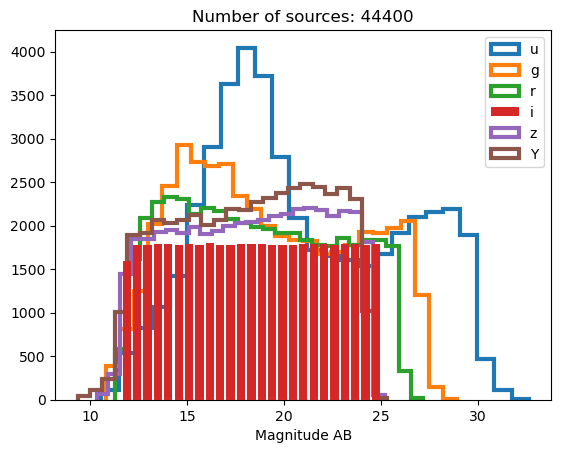

In [56]:
plt.title('Number of sources: ' +str(len(uniform_df['i'])))
for f in 'ugrizY':
    if not f=='i':
        plt.hist(uniform_df[f],bins=25, histtype='step',linewidth=3,label=f)
    else:
        plt.hist(uniform_df[f],bins=25, linewidth=3,label=f,rwidth=0.8,zorder=5)
    plt.xlabel('Magnitude AB')
plt.legend(loc='best')

In [30]:
uniform_df.to_csv('/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/chunks_TRILEGAL_GENULENS/uniform.csv', index=False)

In [ ]:
# len(uniform_stars['Y'])
# len(TRILEGAL)

In [ ]:
import h5py
import numpy as np
from astropy.table import Table

def read_sim_const(path_to_file):
    with h5py.File(path_to_file, 'r') as file:
        # Leer metadata general
        general_data = file['Data'][()]
        general_data = [x.decode() if isinstance(x, bytes) else x for x in general_data]

        # Leer TRILEGAL_params
        event_params = dict(file['TRILEGAL_params'].attrs.items())

        # Leer lightcurves (cada grupo como tabla)
        lightcurves = {}
        for group_name in file:
            if group_name in ['Data', 'TRILEGAL_params']:
                continue
            group = file[group_name]
            table_data = {col: group[col][()] for col in group}
            lightcurves[group_name] = Table(table_data)

    return general_data, event_params, lightcurves

path = '/home/anibal-pc/Event_20.h5'
general_data, event_params, lightcurves = read_sim_const(path)

print("General data:", general_data)
print("TRILEGAL params:", event_params)
print("Bandas:", list(lightcurves.keys()))
# print("Primera tabla:")
# print(lightcurves[list(lightcurves.keys())[0]])

In [ ]:
for f in filters:
    plt.errorbar(constant_lc[f]['time'], constant_lc[f]['mag'],
                 constant_lc[f]['err_mag'], 
                 marker='.', ls='', capsize=2)